## Imports used in this notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from xgboost import plot_importance

In [ ]:
#loading the dataset using pandas and storing it in df
df = pd.read_csv(r"/content/drive/MyDrive/Fraud.csv")

## Understanding our data

In [ ]:
#size of the data
df.shape

(6362620, 11)

In [ ]:
#how data looks
df.sample(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1795913,162,CASH_OUT,227735.88,C276352957,84947.00,0.00,C1414705735,0.00,227735.88,0,0
82442,10,PAYMENT,7216.26,C1895464206,0.00,0.00,M713690388,0.00,0.00,0,0
4927800,350,CASH_OUT,163794.04,C1262492380,237202.00,73407.96,C1070050758,0.00,163794.04,0,0
5684207,397,PAYMENT,7174.57,C1380723140,26624.00,19449.43,M1125489869,0.00,0.00,0,0
6203302,585,PAYMENT,4818.08,C698618108,75542.00,70723.92,M1373106328,0.00,0.00,0,0
1426289,139,PAYMENT,3598.38,C1204373581,13151.00,9552.62,M884419937,0.00,0.00,0,0
6107864,525,CASH_OUT,148105.78,C1399668110,0.00,0.00,C465339989,221725.99,369831.77,0,0
4246563,306,PAYMENT,19117.43,C1299131232,0.00,0.00,M883219968,0.00,0.00,0,0
1541543,154,CASH_OUT,188120.38,C1963413582,20146.00,0.00,C867071553,248533.31,436653.69,0,0
2273140,187,CASH_IN,67081.16,C1201763856,1421927.18,1489008.34,C1281994800,1787456.84,1720375.68,0,0


In [ ]:
#getting datatypes of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
#checking for null values in each column
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


- we don't have any missing values in any column

In [ ]:
#how does the data looks mathematically?
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


**step (Time)**
- min = 1
- max = 743
- ~743 hours ≈ ~31 days of data
- Inference:
  - Dataset covers ~1 month of transactions
  - we can extract time-based patterns

**amount**
- mean ≈ 1.8 lakh
- max ≈ 9.2 crore
- std is very high
- HUGE difference between mean & max
- Inference:
  - Data has extreme outliers
  - Some transactions are abnormally large → possible fraud

**Sender Balance (oldbalanceOrg, newbalanceOrig)**
- Key observation:
  - 25% = 0
  - median (50%) = very low or 0
- Inference:
  - Many users have zero balance
  - OR data has many inactive/empty accounts

**Receiver Balance (oldbalanceDest, newbalanceDest)**
- Also has:
  - min = 0
  - large max (hundreds of millions)
- Inference:
  - Huge variation in receiver accounts
- Mix of:
  - small users
  - very large accounts (maybe businesses)

**isFraud**
- mean = 0.00129
- Convert: ≈ 0.13% fraud
- Inference:
  - Dataset is EXTREMELY imbalanced

**“Fraud transactions are very rare (~0.13%), making this a highly imbalanced classification problem.”**

**isFlaggedFraud**
- mean = 0.0000025 (almost zero)
- Inference:
  - System barely flags fraud
  - Not reliable
  
**“The built-in fraud flag feature has very low positive cases, making it less useful for prediction.”**

**Hidden Insights**
1. Median vs Mean (VERY POWERFUL)
- Example:
    - amount:
        - mean = 1.8 lakh
        - median = 74k
    - mean >> median
- Inference:
    - Data is right-skewed
    - Few large transactions dominate

2. Many Zeros in Balances
- Suggests:
    - Many accounts start with 0
    - Possible fraud pattern:
    - empty → sudden large transfer

3. Huge Standard Deviation
- For almost all columns
    - std is very high
- Inference:
    - Data is highly spread out
    - Scaling may help

In [ ]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

<Axes: >

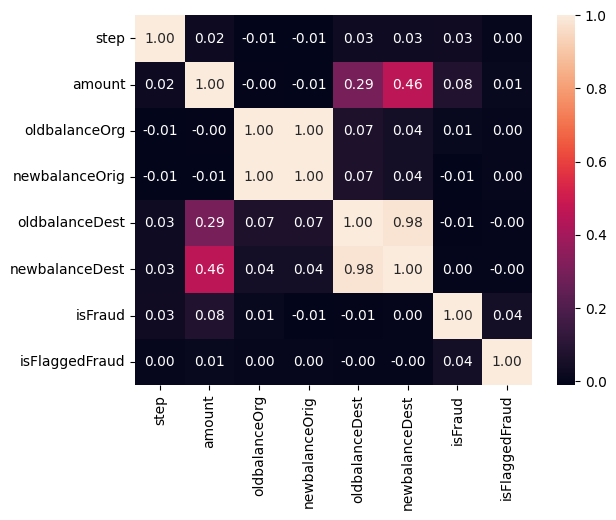

In [ ]:
#how is the correlation between columns
corr = df.corr(numeric_only=True)

sns.heatmap(corr,annot=True,fmt=".2f")

1. oldbalanceOrg ↔ newbalanceOrig = 1.00
- Perfect correlation
- Meaning: These two are almost the same information
- Example: newbalanceOrig = oldbalanceOrg - amount
- Inference:
    - This is redundant data (duplicate information)
- we can:
    - Drop one of them

2. oldbalanceDest ↔ newbalanceDest = 0.98
- Very strong correlation
- Meaning: Receiver’s balance before & after are tightly linked
- Inference:
    - Again → redundant information

3. amount ↔ newbalanceDest = 0.46
- Moderate positive correlation
- Meaning: As transaction amount increases → receiver balance increases
- This makes sense logically

 4. amount ↔ oldbalanceDest = 0.29
- Weak to moderate correlation
- Again logical: Bigger accounts receive bigger transactions

5. MOST IMPORTANT: isFraud correlations

|Feature | Correlation with Fraud|

|amount | 0.08|

|step |	0.03|

|balances |	~0|

- VERY LOW correlations
- BIG INSIGHT: No single feature strongly predicts fraud
- What this means:
    - Fraud detection is NOT:
        - “If amount is high → fraud”
    - It is:
        - Combination of multiple features

6. isFlaggedFraud ↔ isFraud = 0.04
- Almost no correlation
- Inference:
    - Built-in system is not reliable
    - our model can outperform it

**Advanced Insight**
- Since correlations with isFraud are low:

**“Fraud detection is a non-linear problem where patterns cannot be captured using simple linear relationships, requiring advanced models like tree-based algorithms.”**

`“This is a complex problem → requires smart modeling”`

## Univariate Analysis

In [ ]:
cat = ["type","isFraud","isFlaggedFraud"]
num = ["step","amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

### Categorical Data

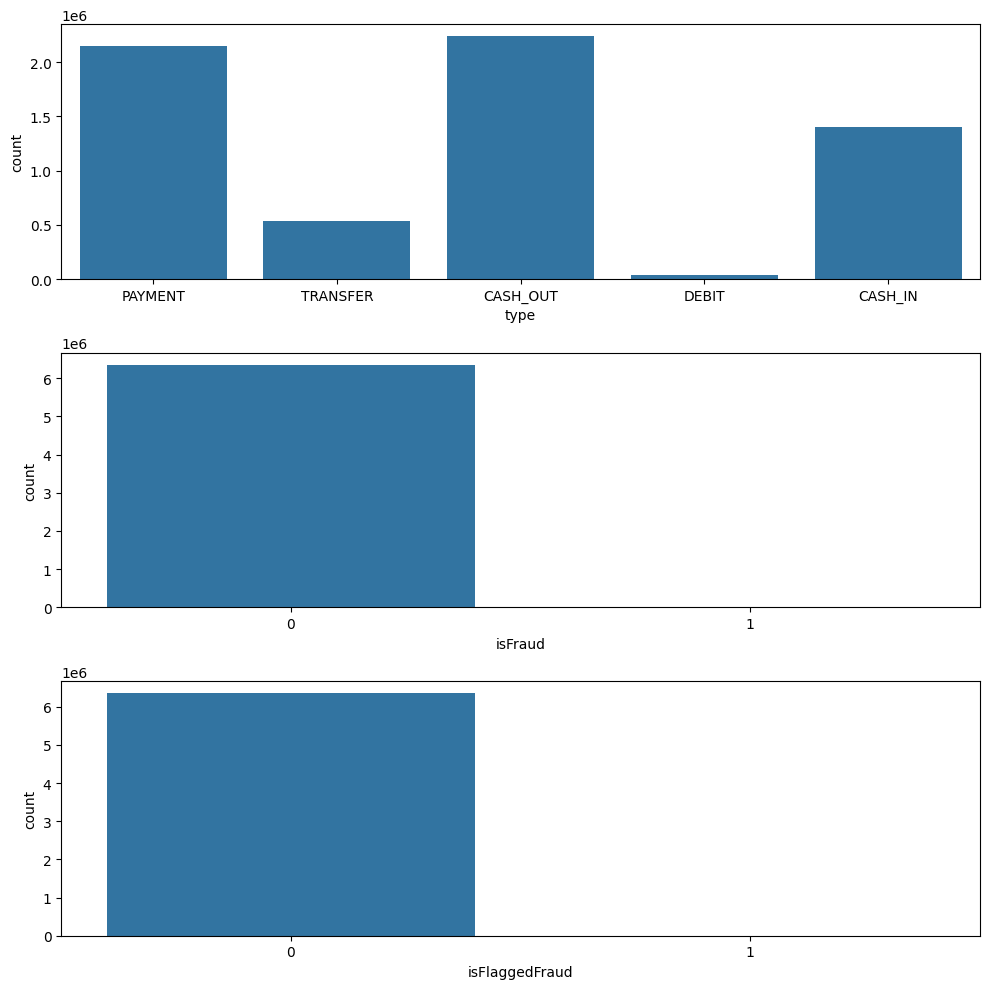

In [ ]:
#contplot

fig,ax = plt.subplots(nrows=3,ncols=1,figsize=(10,10))
ax = ax.flatten()
for i,col in enumerate(cat):
    sns.countplot(data=df,x=col,ax=ax[i])
plt.tight_layout()

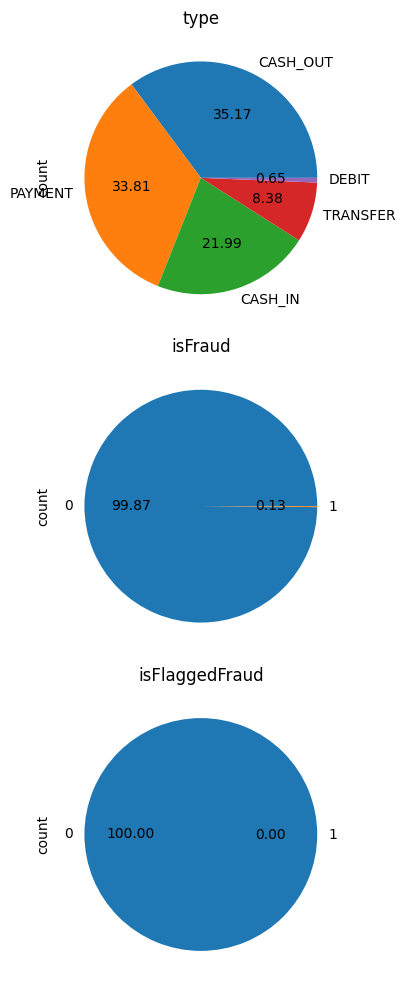

In [ ]:
#pie chart

fig,ax = plt.subplots(nrows=3,ncols=1,figsize=(10,10))
ax = ax.flatten()
for i,col in enumerate(cat):
    df[col].value_counts().plot(kind='pie',autopct='%.2f',ax=ax[i])
    ax[i].set_title(col)
plt.tight_layout()

- Transactions are dominated by a few types
- Fraud is extremely rare
- System flag is almost useless

In [ ]:
df.drop(columns=['isFlaggedFraud'],axis=1,inplace=True)

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


`“I dropped the isFlaggedFraud feature because it had extremely low variance and very weak correlation with the target variable. Additionally, since it represents an existing rule-based system, including it could introduce bias and reduce the model’s ability to learn independent fraud patterns.”`

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [ ]:
df['isFraud'].value_counts(normalize=True)*100

,proportion
isFraud,
0,99.870918
1,0.129082


- target column is highly imbalanced

In [ ]:
cat = ["type","isFraud",]
num = ["step","amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

### Numerical Data

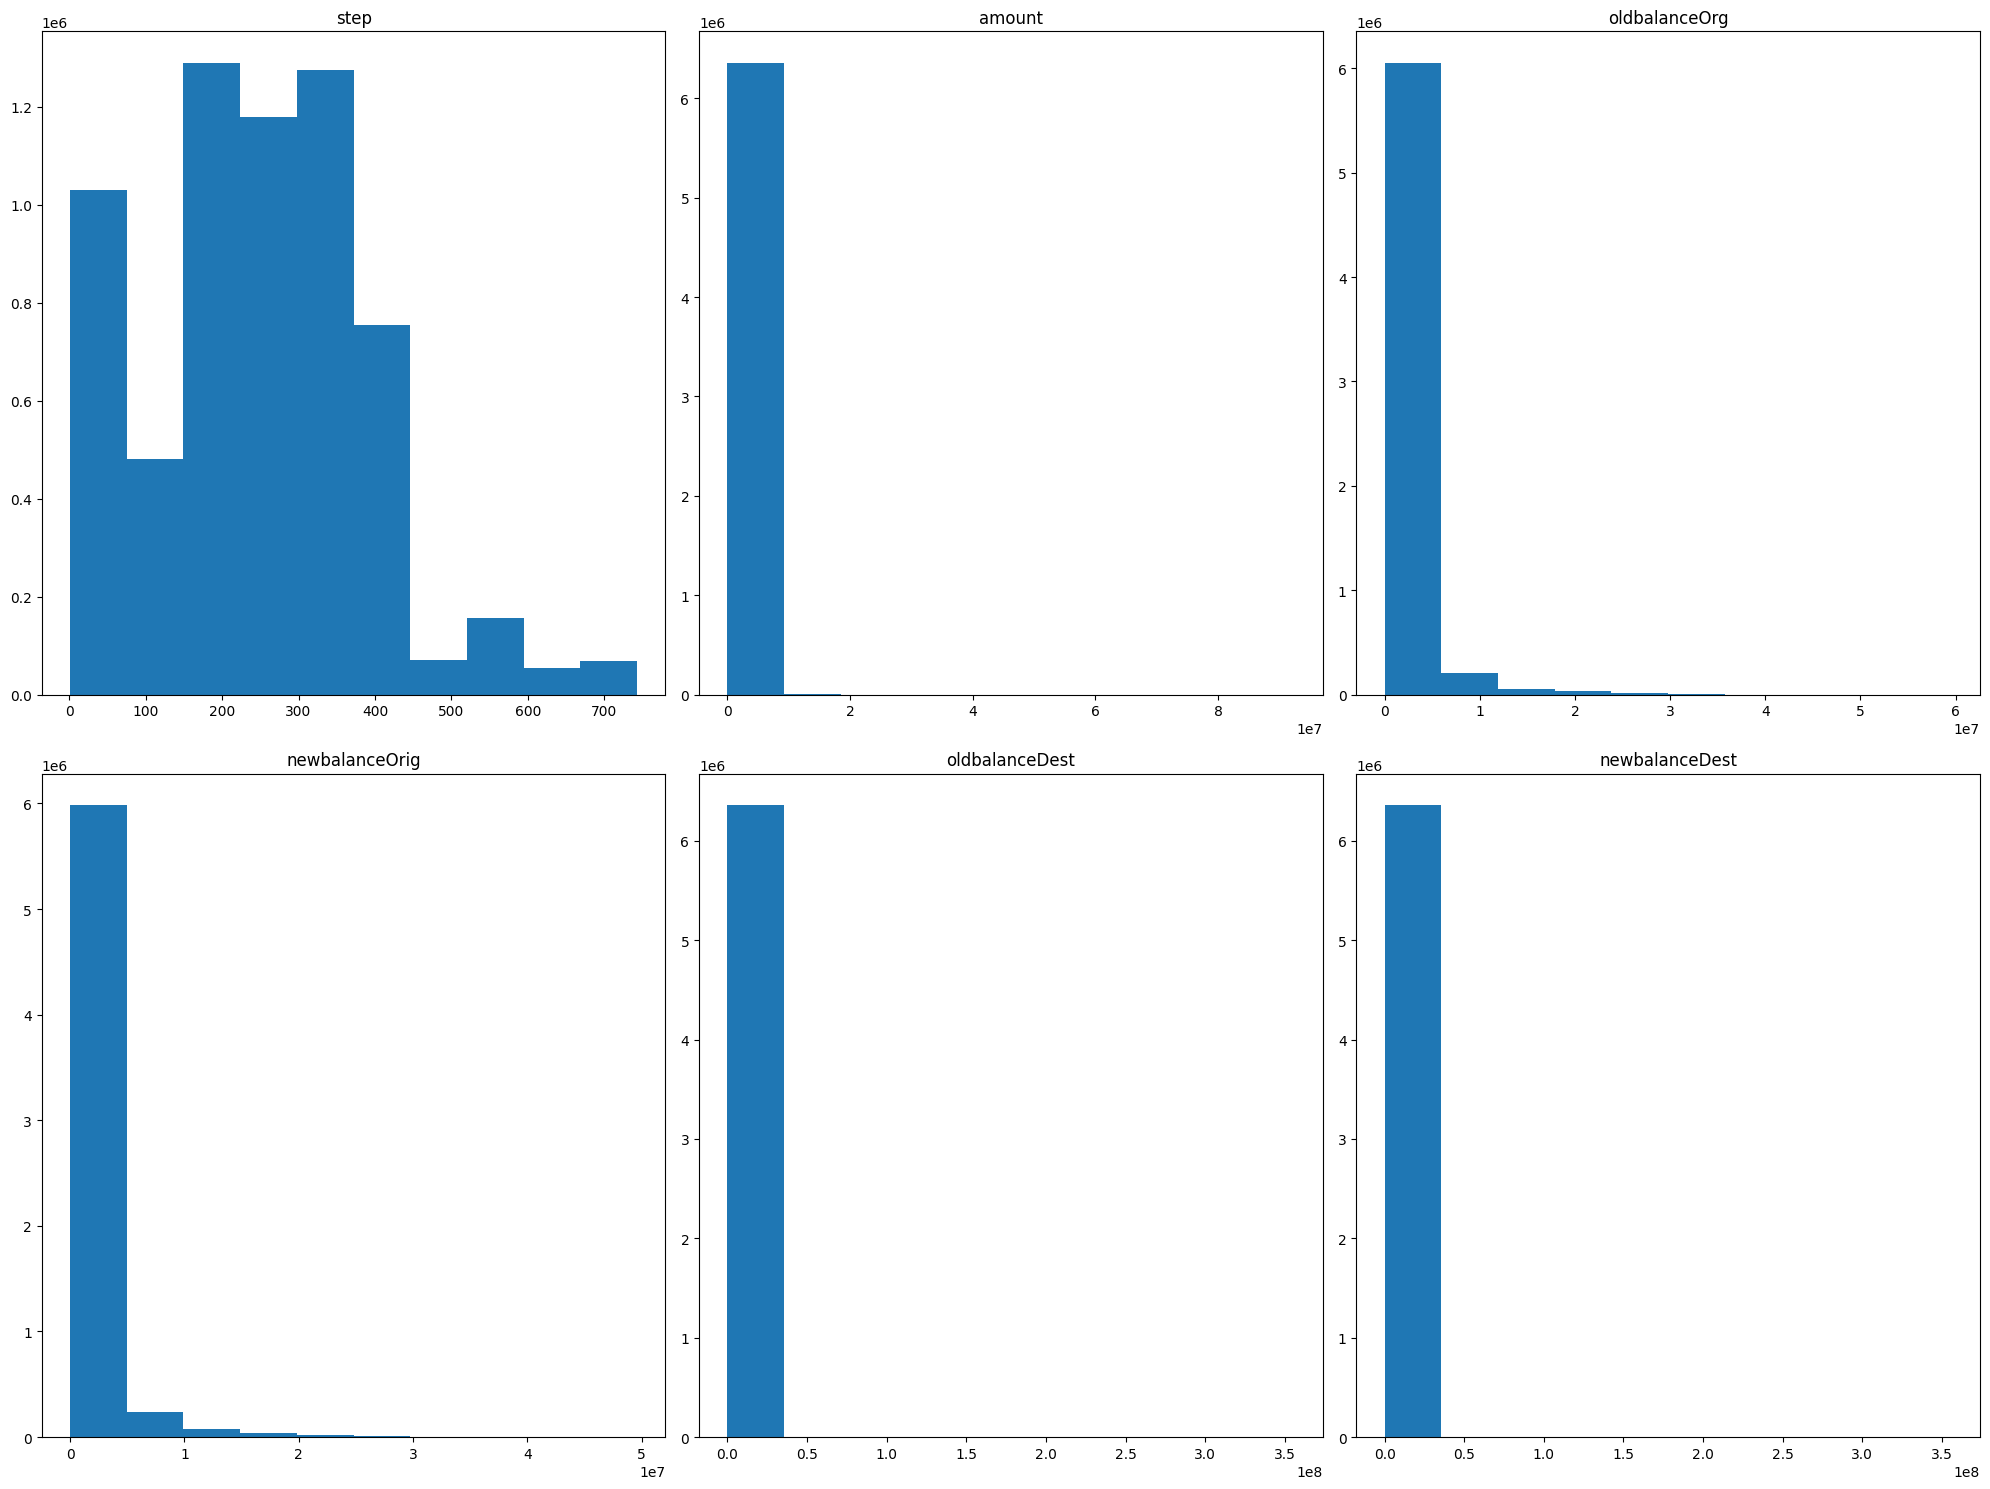

In [ ]:
#1.histogram

fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(20,15))
ax = ax.flatten()

for i,col in enumerate(num):
    ax[i].hist(df[col])
    ax[i].set_title(col)
plt.tight_layout()

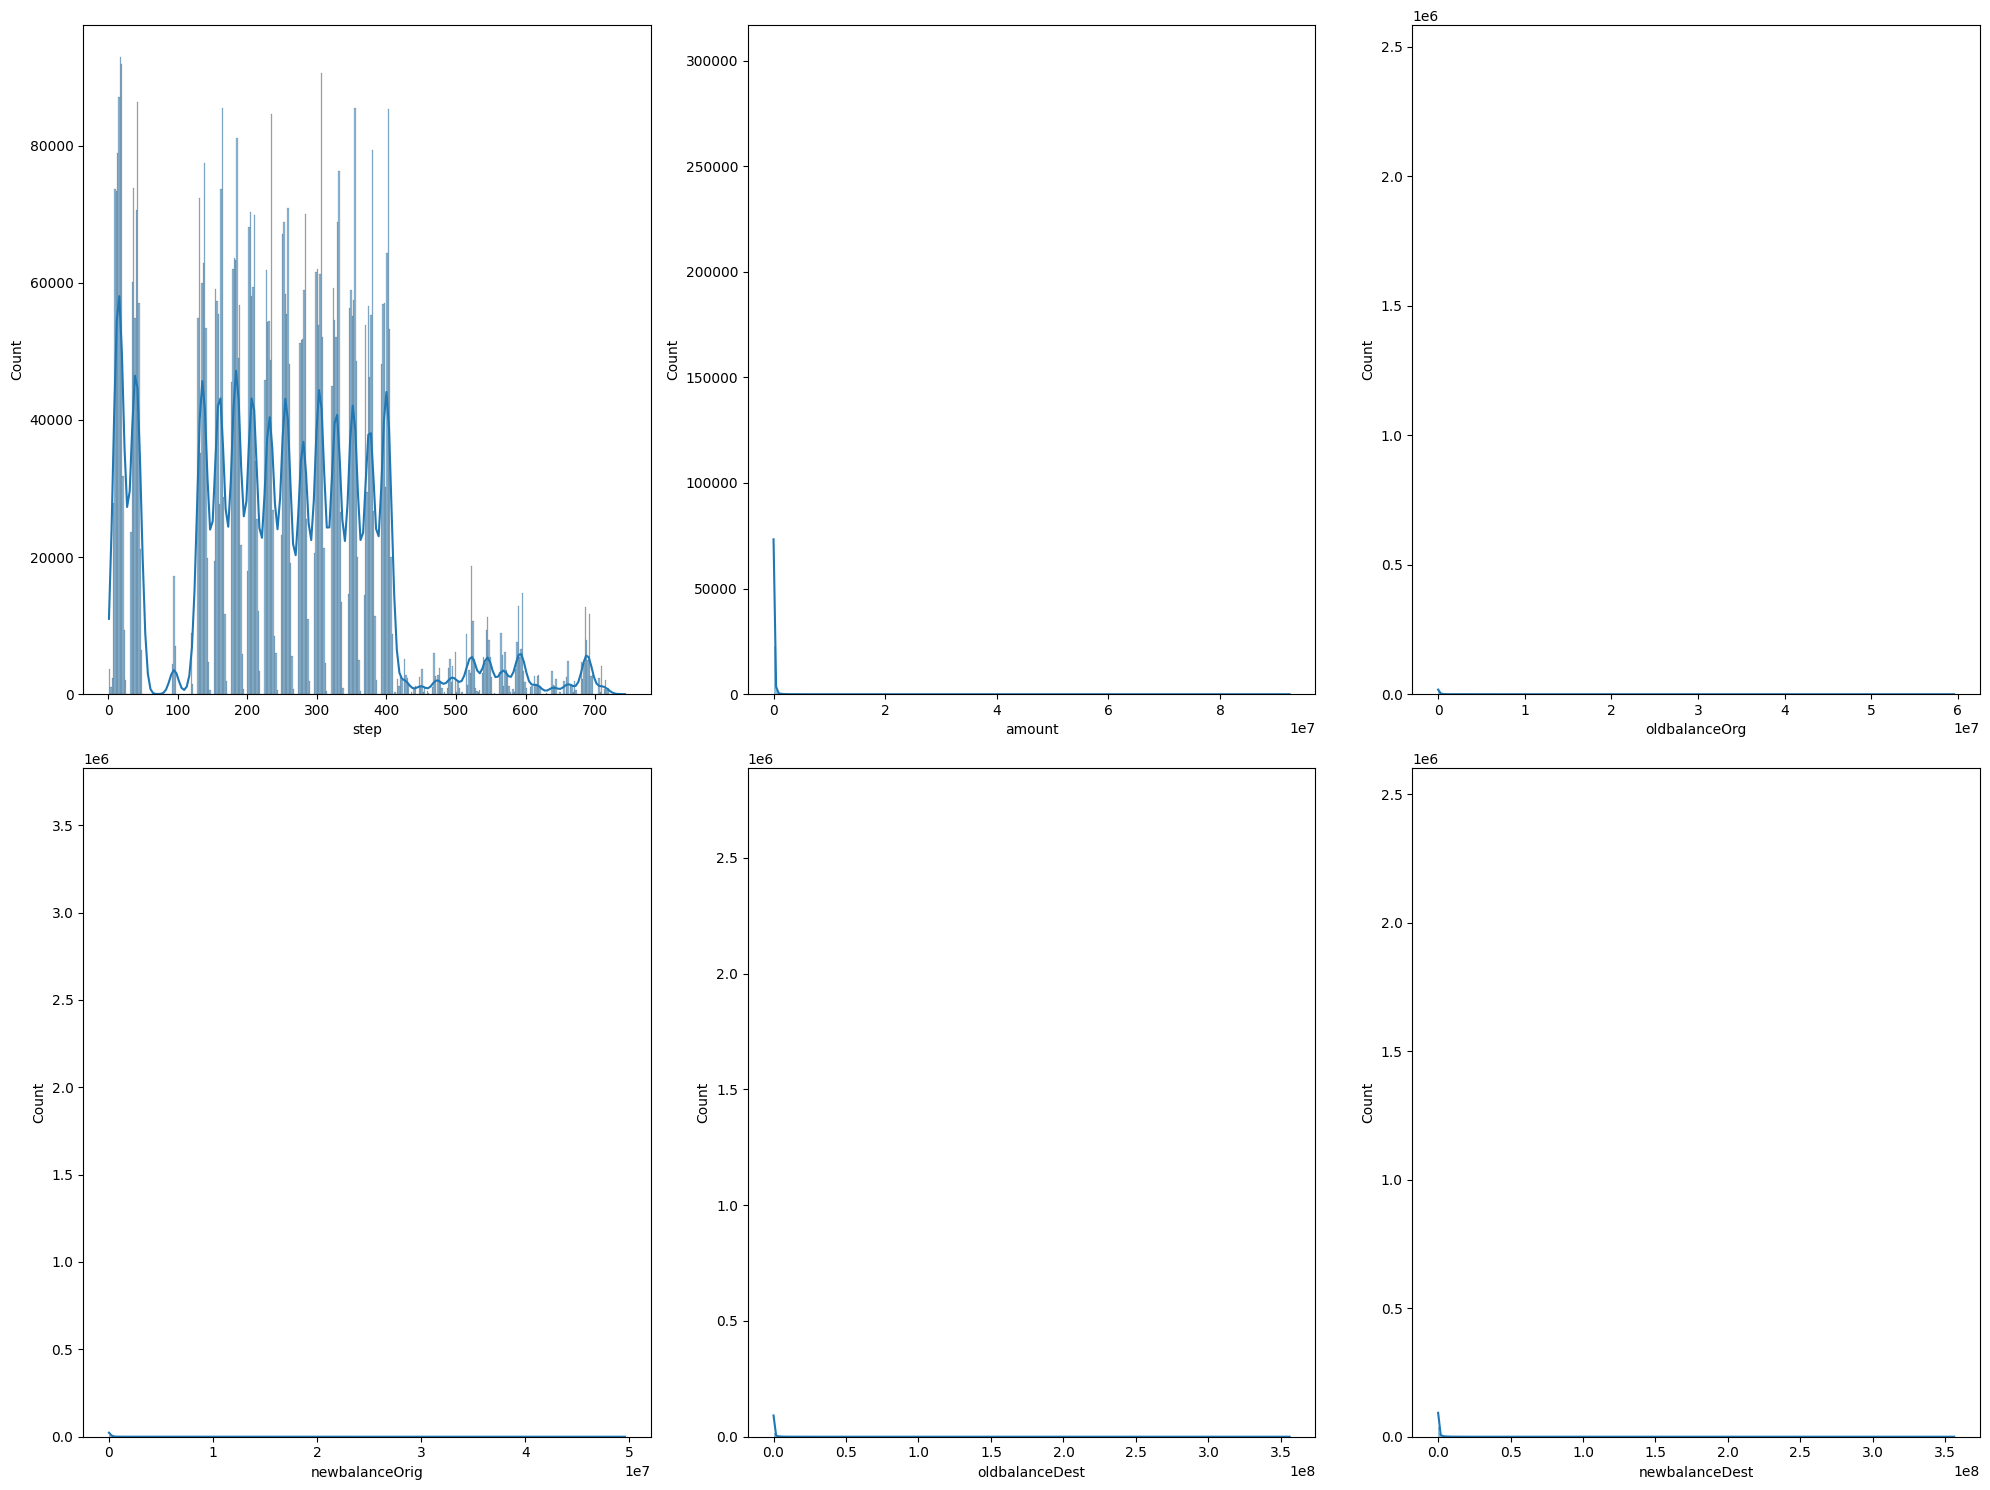

In [ ]:
#2.distribution plot
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(20,15))
ax = ax.flatten()

for i,col in enumerate(num):
    sns.histplot(df[col],ax=ax[i],kde=True)
plt.tight_layout()

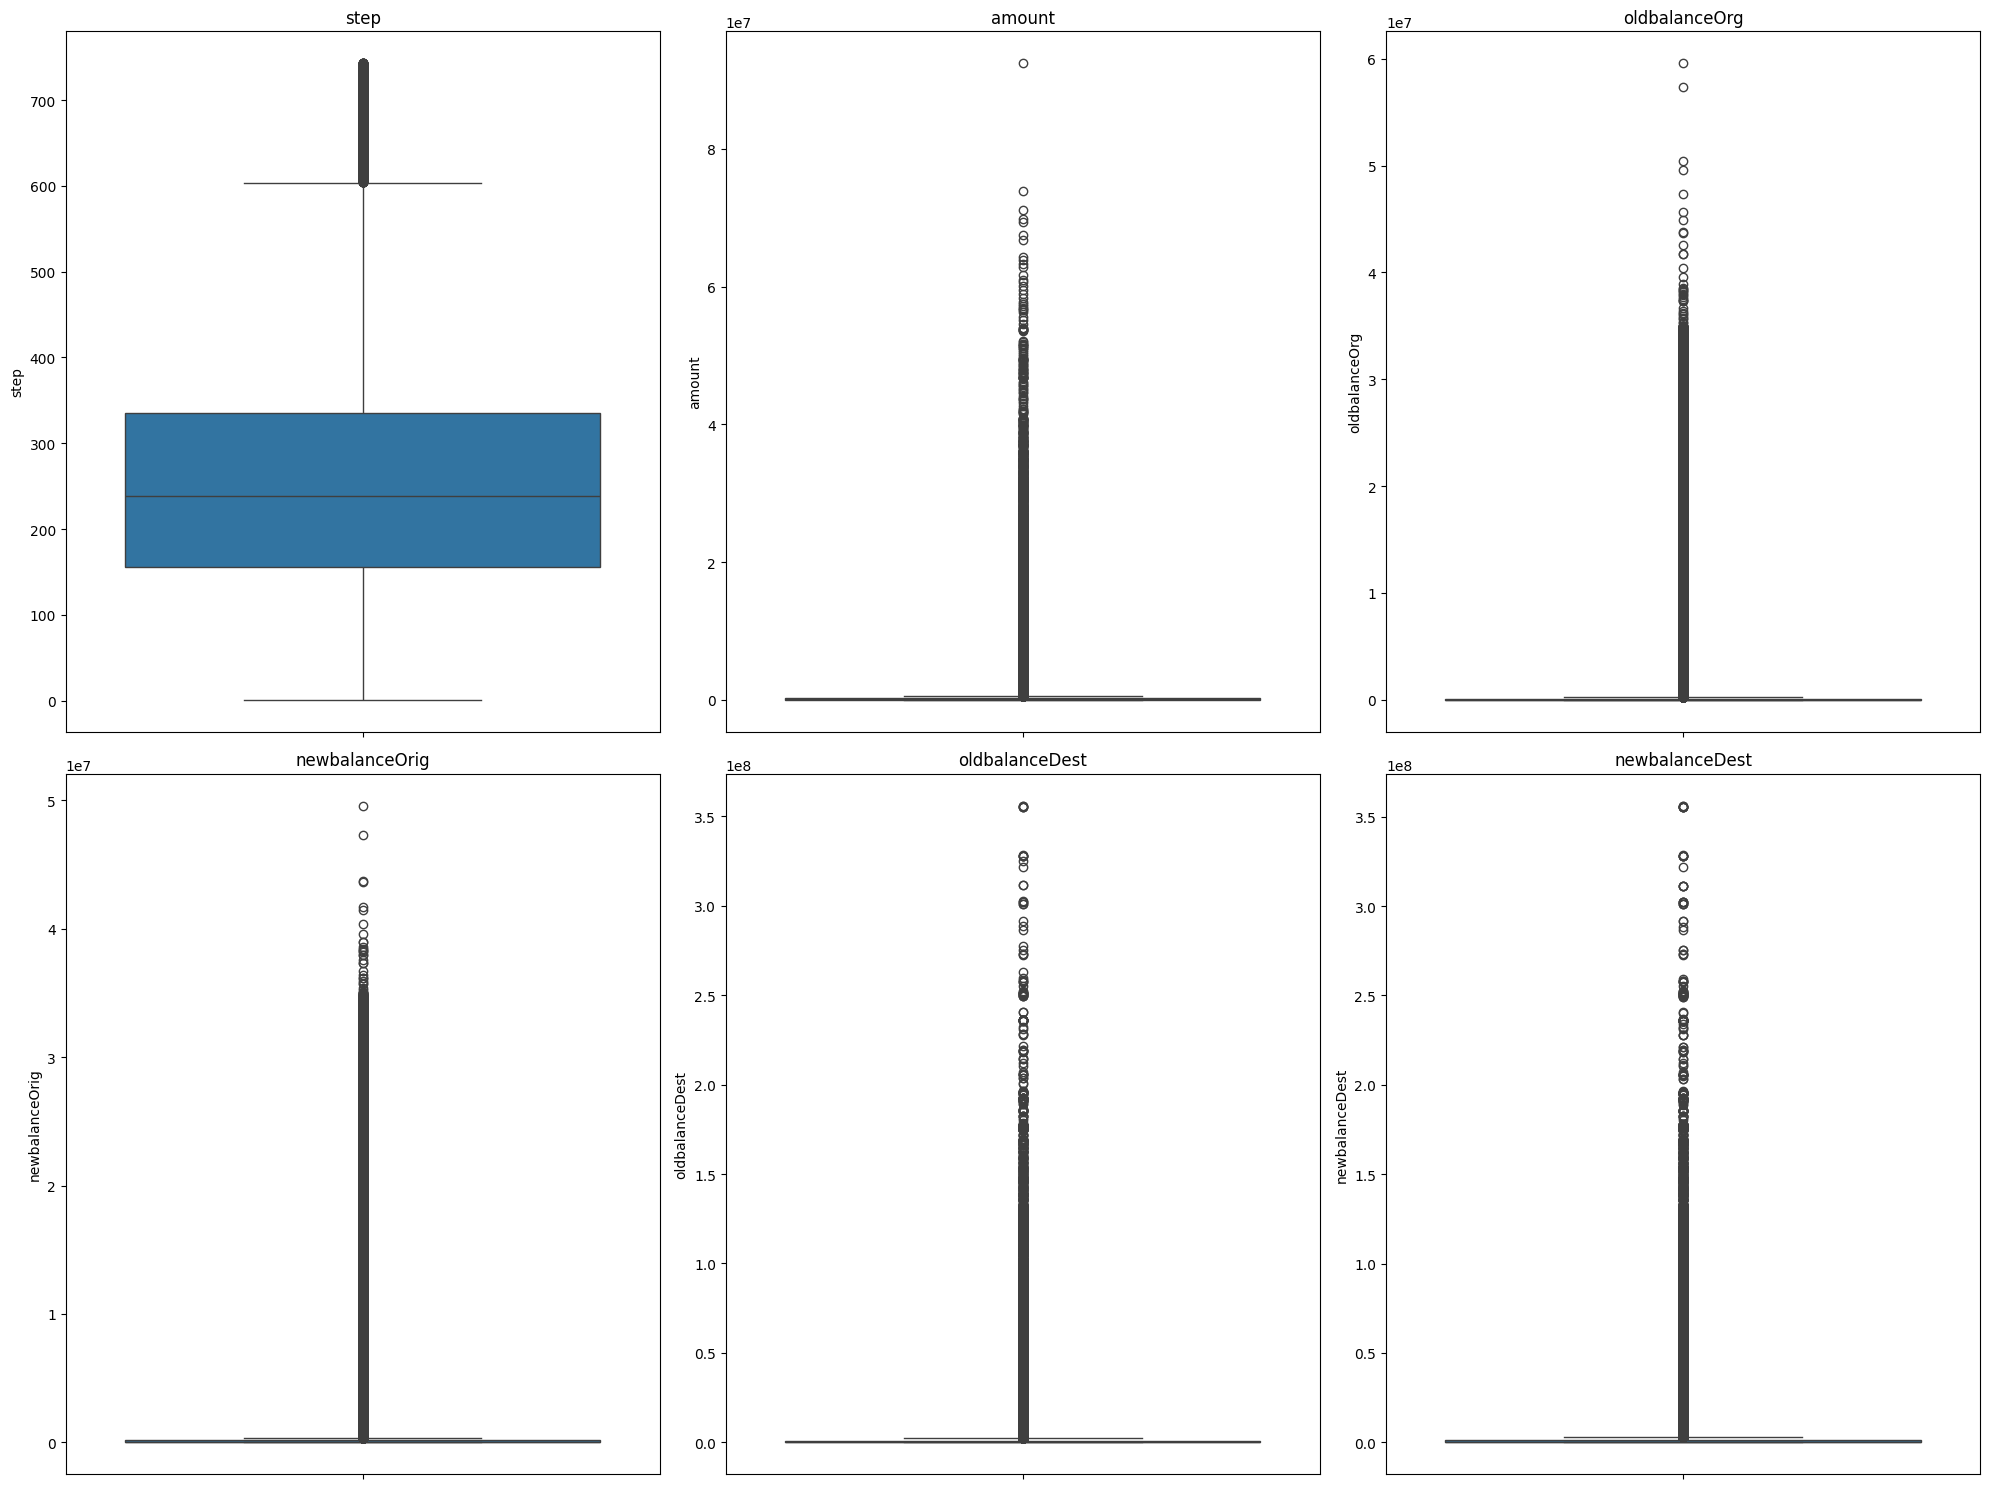

In [ ]:
#3.box plot
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(20,15))
ax = ax.flatten()

for i,col in enumerate(num):
    sns.boxplot(df[col],ax=ax[i])
    ax[i].set_title(col)
plt.tight_layout()

1. step
- Observation:
    - Fairly spread out
    - Slight variation across time
- Inference:
    - Data is distributed across the entire time period (~1 month)

`No strong skew → good feature`

2. amount
- Observation:
    - Most values near 0
    - Few extremely large values
    - Heavy right skew
- Inference:
    - Most transactions are small, but a few transactions are extremely large, indicating the presence of outliers.
- Real-world meaning:
    - Fraud often involves:
        - unusually large transactions

3. oldbalanceOrg
- Observation:
    - Huge spike at 0
    - Long tail
- Inference:
    - A large number of users have zero or very low balance.

4. newbalanceOrig
- Observation:
    - Same pattern as above
- Inference:
    - Many accounts end up with zero balance after transactions.
- Possible:
    - full withdrawals
    - suspicious behavior

5. oldbalanceDest
- Observation:
    - Most values small
    - Few extremely large
- Inference:
    - Receiver accounts vary widely, from very small to very large balances.

6. newbalanceDest
- Observation:
    - Same pattern
- Inference:
    - Large variation in receiver balances after transactions.

## Bivariate Analysis

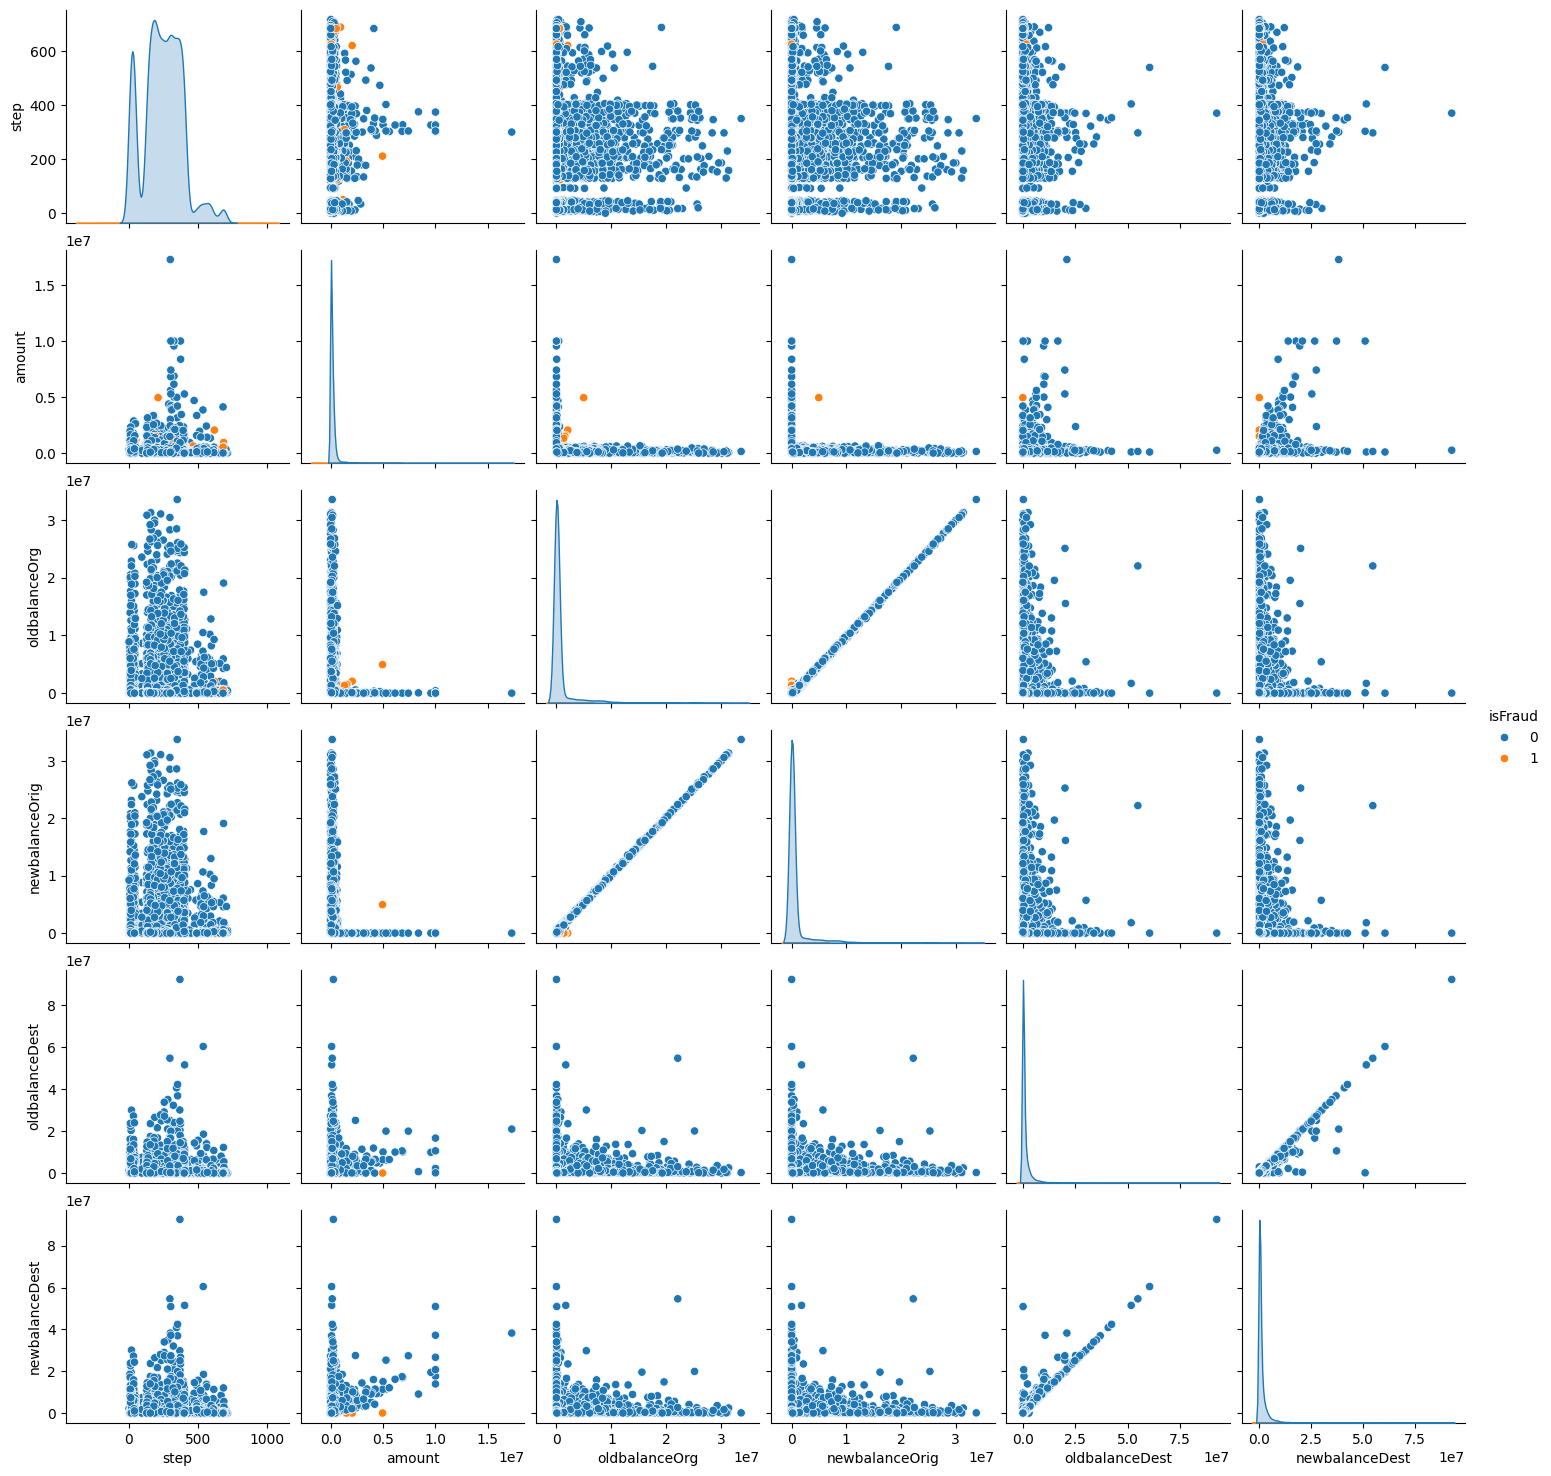

In [ ]:
#Numerical vs Numerical

#pairplot

df_sample = df.sample(10000, random_state=42)
sns.pairplot(df_sample, hue='isFraud')

In [ ]:
#calculating skewness mathematically

df[num].skew()

,0
step,0.375177
amount,30.993949
oldbalanceOrg,5.249136
newbalanceOrig,5.176884
oldbalanceDest,19.921758
newbalanceDest,19.352302


- all numerical columns are **Highly positively skewed**

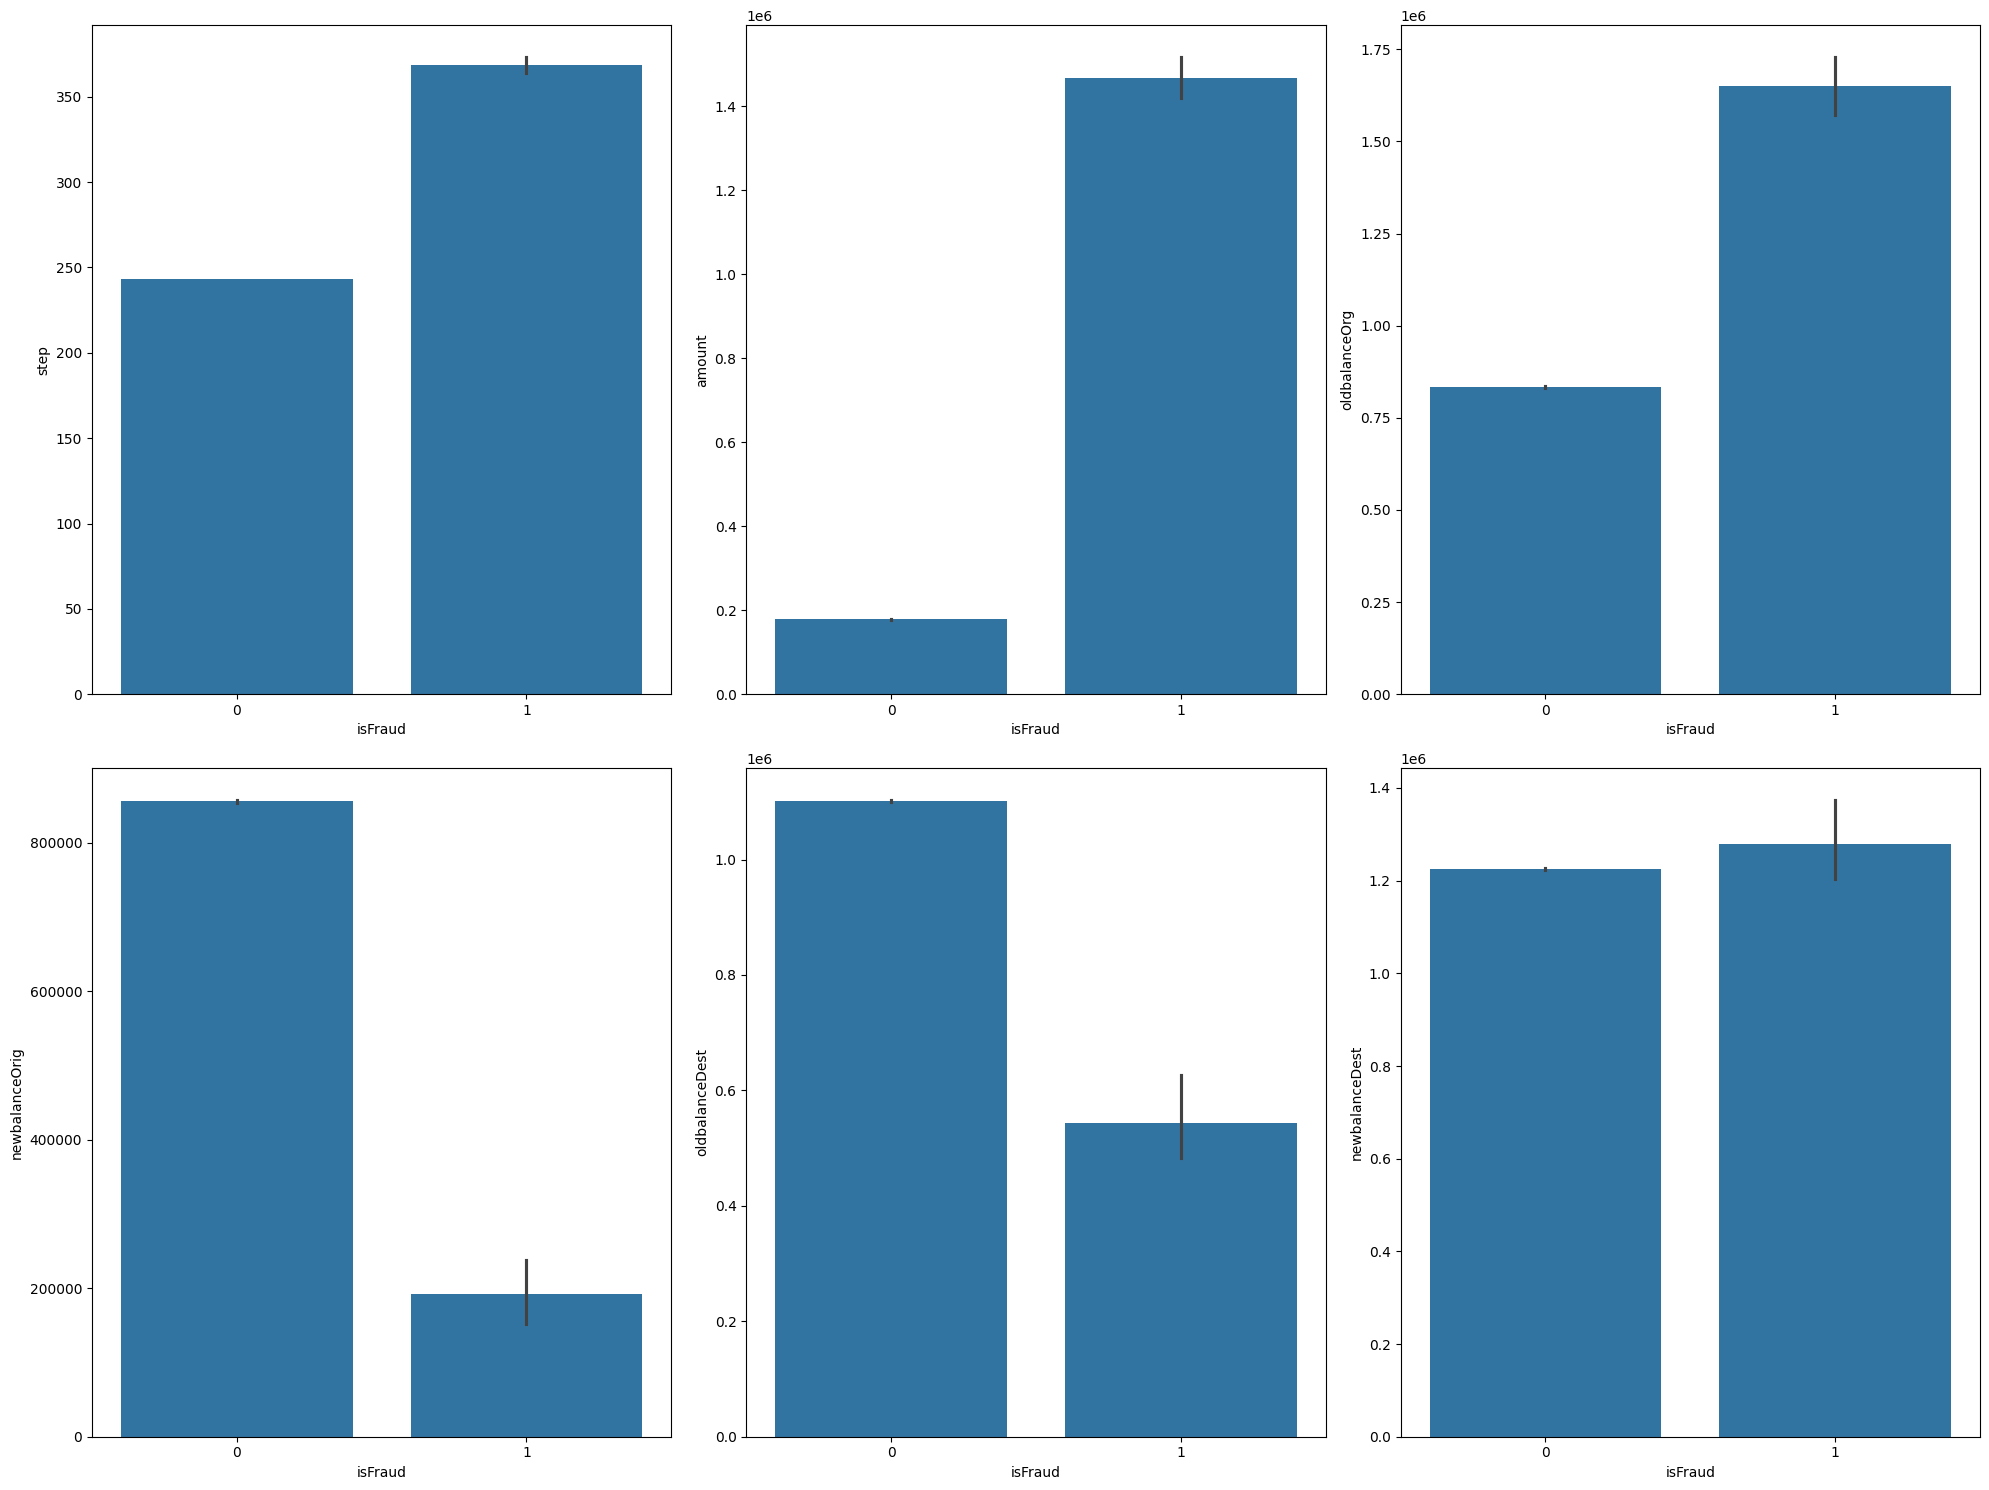

In [ ]:
#categorical vs numerical (target vs num_cols)

fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(20,15))
ax = ax.flatten()

for i,col in enumerate(num):
    sns.barplot(x=df['isFraud'],y=df[col],ax=ax[i])
plt.tight_layout()

- **isFraud** vs **amount** -> Fraud transactions usually involve larger amounts.
- **isFraud** vs **oldbalanceOrg** -> Fraud happens when we have more money in our account
- **isFraud** vs **newbalanceOrig** -> when fraud happens our account balance gets reduced compared to when fraud does not happes
- **oldbalanceDest** vs **isFraud**
    - Fraud cases have lower destination balance initially
    - Meaning:
        - Money is being sent to:
            - New accounts
            - Less active accounts
- **newbalanceDest** vs **isFraud**
    - Fraud → higher destination balance after transaction
    - Means:
        - Money is successfully transferred
- since we have class imbalance in isFraud column we can't draw so much of conclusion by considering only mean so let's plot some other plots to get more insights

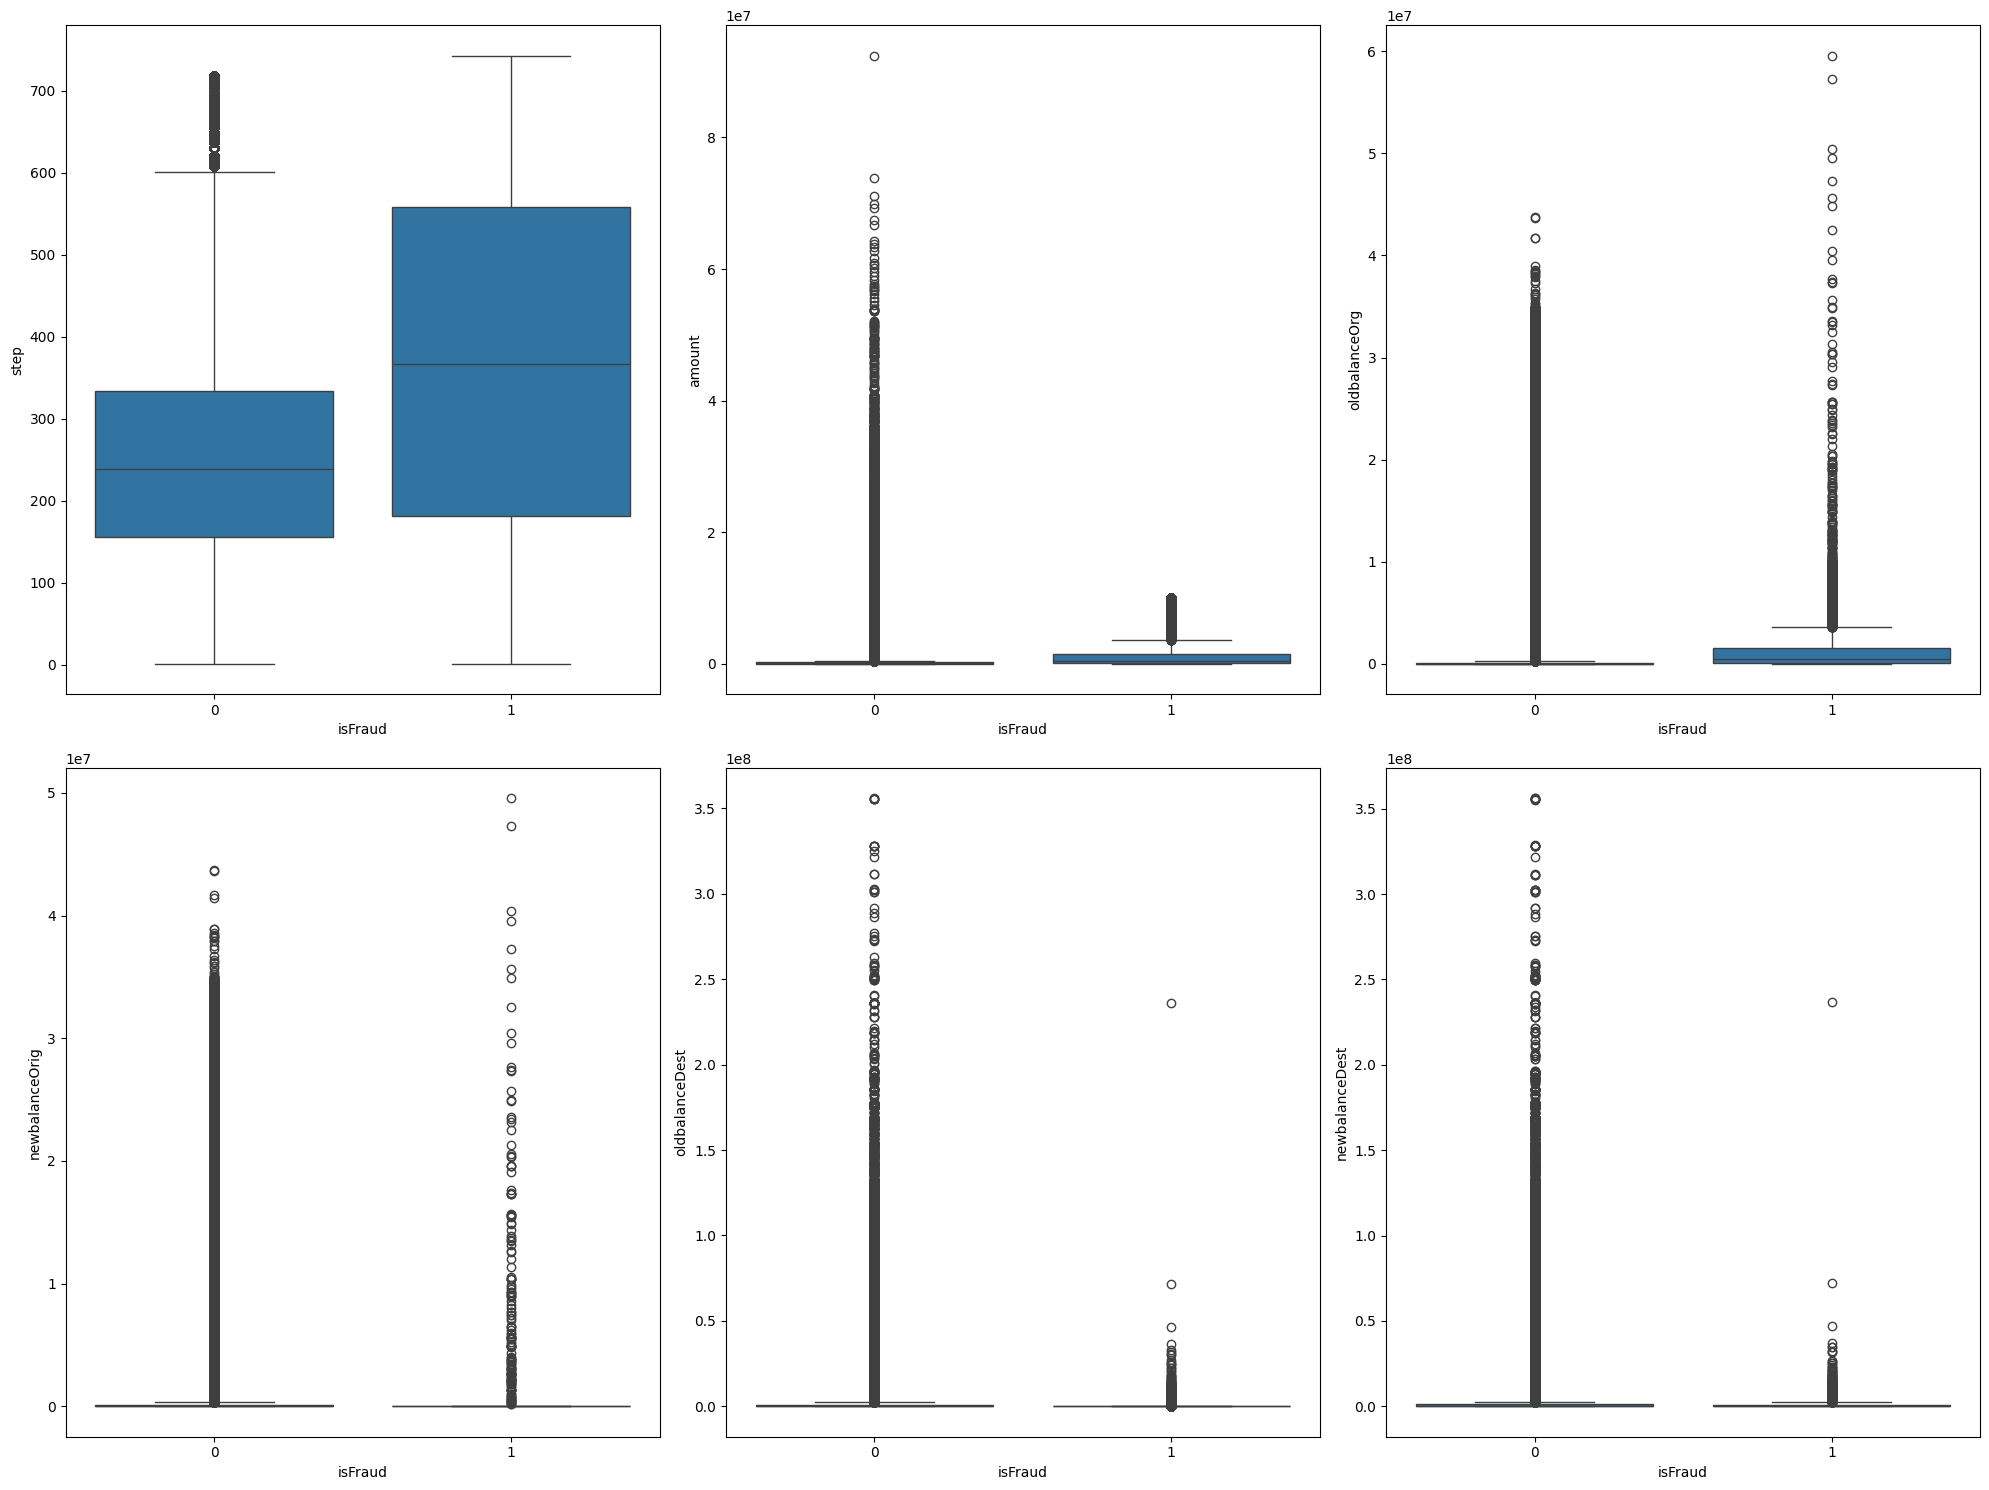

In [ ]:
#numerical vs categorical
fig,ax = plt.subplots(nrows=2,ncols=3,figsize=(20,15))
ax = ax.flatten()

for i,col in enumerate(num):
    sns.boxplot(x='isFraud', y=col, data=df,ax=ax[i])
plt.tight_layout()

- Fraud Transactions Have Higher Medians [amount , oldbalanceOrg , newbalanceOrig]
- Fraud Often Happens When Sender Balance Drops to Zero [oldbalanceOrg , newbalanceOrig]
- Destination Balances Are Less Informative

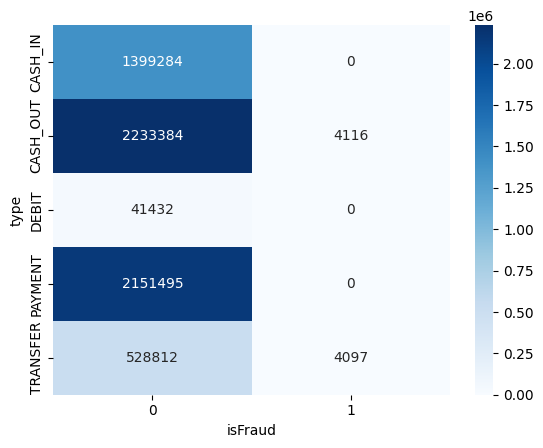

In [ ]:
#categorical vs categorical

ct = pd.crosstab(df['type'], df['isFraud'])

sns.heatmap(ct, annot=True, fmt='d', cmap='Blues')
plt.show()

- more number of fruads are happening during **CASH_OUT** and **TRANSFER**
- This means:
    - Fraudsters transfer money first
    - Then cash it out

`📈 Business Insight`

- Fraud monitoring systems should:
    - Add stricter checks on TRANSFER
    - Add withdrawal limits for suspicious accounts

In [ ]:
# !pip install ydata-profiling

In [ ]:
# from ydata_profiling import ProfileReport

# prof = ProfileReport(df)
# prof.to_file(output_file='output.html')

## Feature Engineering

In [ ]:
df['hour'] = df['step'] % 24
df['day'] = df['step'] // 24

In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour,day
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,1,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,1,0


In [ ]:

df['balance_diff_org'] = df['oldbalanceOrg'] - df['amount'] - df['newbalanceOrig']

In [ ]:
(len(df[(df['balance_diff_org']!=0) & (df['isFraud']==1)]) / len(df[df['isFraud']==1]))*100

1.5463289906246194

- when balance_diff_org != 0 then we can say that it may be a fraud
- but only 1.54% show balance inconsistency
- That means 98.46% of fraud transactions are perfectly balance-consistent

In [ ]:
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

In [ ]:
(len(df[(df['balance_diff_dest']!=0) & (df['isFraud']==1)]) / len(df[df['isFraud']==1]))*100

73.56629733349568

In [ ]:
(len(df[(df['balance_diff_dest']!=0) & (df['isFraud']==0)]) / len(df[df['isFraud']==0])) * 100

88.06829653813487

- Although 73% of fraud transactions exhibited destination balance inconsistencies, further analysis showed that 88% of non-fraud transactions also had similar inconsistencies. Hence, this feature does not provide strong discriminatory power between fraudulent and legitimate transactions.

In [ ]:
# Droping Identifier Columns (High Cardinality, No Predictive Power)
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

In [ ]:
#Account Drained Feature
df['is_drained'] = (df['newbalanceOrig'] == 0).astype(int)

In [ ]:
#High Transaction Feature
df['high_amount'] = (df['amount'] > df['amount'].quantile(0.90)).astype(int)

In [ ]:
#No Balance Before Transaction
df['zero_balance_before'] = (df['oldbalanceOrg'] == 0).astype(int)

In [ ]:
#No Balance After Transaction
df['zero_balance_after'] = (df['newbalanceOrig'] == 0).astype(int)

In [ ]:
#these columns will cause data leakage while training the model
df.drop(['newbalanceOrig','newbalanceDest'],axis=1,inplace=True)

In [ ]:
#Ratio-Based Features
df['amount_to_balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

In [ ]:
#Night Transaction Feature
df['is_night'] = df['hour'].apply(lambda x: 1 if x < 6 else 0)

In [ ]:
#encoding categorical data
#one-hot encoding

df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 15 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   step                     int64  
 1   amount                   float64
 2   oldbalanceOrg            float64
 3   oldbalanceDest           float64
 4   isFraud                  int64  
 5   hour                     int64  
 6   day                      int64  
 7   high_amount              int64  
 8   zero_balance_before      int64  
 9   amount_to_balance_ratio  float64
 10  is_night                 int64  
 11  type_CASH_OUT            bool   
 12  type_DEBIT               bool   
 13  type_PAYMENT             bool   
 14  type_TRANSFER            bool   
dtypes: bool(4), float64(4), int64(7)
memory usage: 558.2 MB


- Pandas generated boolean dummy variables, which are internally treated as binary values by scikit-learn models, so no additional conversion is required.

In [ ]:
df['amount'] = np.log1p(df['amount'])
df['oldbalanceOrg'] = np.log1p(df['oldbalanceOrg'])
df['oldbalanceDest'] = np.log1p(df['oldbalanceDest'])

In [ ]:
df.head()

,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,hour,day,high_amount,zero_balance_before,amount_to_balance_ratio,is_night,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9.194276,12.044359,0.000000,0,1,0,0,0,0.057834,1,False,False,True,False
1,1,7.531166,9.964112,0.000000,0,1,0,0,0,0.087731,1,False,False,True,False
2,1,5.204007,5.204007,0.000000,1,1,0,0,0,0.994505,1,False,False,False,True
3,1,5.204007,5.204007,9.960954,1,1,0,0,0,0.994505,1,True,False,False,False
4,1,9.364703,10.634773,0.000000,0,1,0,0,0,0.280788,1,False,False,True,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 15 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   step                     int64  
 1   amount                   float64
 2   oldbalanceOrg            float64
 3   oldbalanceDest           float64
 4   isFraud                  int64  
 5   hour                     int64  
 6   day                      int64  
 7   high_amount              int64  
 8   zero_balance_before      int64  
 9   amount_to_balance_ratio  float64
 10  is_night                 int64  
 11  type_CASH_OUT            bool   
 12  type_DEBIT               bool   
 13  type_PAYMENT             bool   
 14  type_TRANSFER            bool   
dtypes: bool(4), float64(4), int64(7)
memory usage: 558.2 MB


# Train Test split

In [ ]:
# X = df.drop(['isFraud'],axis=1)
# y = df['isFraud']

In [ ]:
# X.head()

,step,amount,oldbalanceOrg,oldbalanceDest,hour,day,balance_diff_org,balance_diff_dest,is_drained,high_amount,zero_balance_before,zero_balance_after,amount_to_balance_ratio,is_night,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9.194276,12.044359,0.000000,1,0,0.0,-9839.64,0,0,0,0,0.057834,1,False,False,True,False
1,1,7.531166,9.964112,0.000000,1,0,0.0,-1864.28,0,0,0,0,0.087731,1,False,False,True,False
2,1,5.204007,5.204007,0.000000,1,0,0.0,-181.00,1,0,0,1,0.994505,1,False,False,False,True
3,1,5.204007,5.204007,9.960954,1,0,0.0,-21363.00,1,0,0,1,0.994505,1,True,False,False,False
4,1,9.364703,10.634773,0.000000,1,0,0.0,-11668.14,0,0,0,0,0.280788,1,False,False,True,False


In [ ]:
# y.head()

,isFraud
0,0
1,0
2,1
3,1
4,0


In [ ]:
#train test split
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

# Modelling

In [ ]:
# models = {
#     "Logistic Regression": LogisticRegression(
#         class_weight='balanced',
#         max_iter=1000
#     ),

#     "Decision Tree": DecisionTreeClassifier(
#         class_weight='balanced',
#         random_state=42
#     ),

#     "Random Forest": RandomForestClassifier(
#         n_estimators=100,
#         class_weight='balanced',
#         random_state=42,
#         n_jobs=-1
#     ),

#     "Gradient Boosting": GradientBoostingClassifier(
#         n_estimators=100,
#         learning_rate=0.1,
#         random_state=42
#     ),

#     "XGBoost": XGBClassifier(
#         n_estimators=200,
#         max_depth=6,
#         learning_rate=0.1,
#         scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
#         random_state=42,
#         n_jobs=-1,
#         eval_metric='logloss'
#     )
# }

In [ ]:
def fit_and_score(models, X_train, y_train, X_test, y_test):
    np.random.seed(42)
    model_scores = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        model_scores[name] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred)
        }

    return model_scores

In [ ]:
# models_score = fit_and_score(models, X_train, y_train, X_test, y_test)

NameError: name 'fit_and_score' is not defined

In [ ]:
# models_score

* From the above values we can guess that data leakage is happening , so the models are performing so well.
* These features:
  - balance_error_orig = oldbalanceOrg - amount - newbalanceOrig
  - balance_error_dest = oldbalanceDest + amount - newbalanceDest
      - These use:
          - newbalanceOrig
          - newbalanceDest
  - But in real-time:
      - we won’t know new balance before transaction completes
`That’s leakage`

# Data Cleaning

In [ ]:
#Removing Leakage Features
df.drop([
    'balance_diff_org',
    'balance_diff_dest',
    'is_drained',
    'zero_balance_after'
], axis=1, inplace=True)

In [ ]:
#Converting bool → int
bool_cols = ['type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
df[bool_cols] = df[bool_cols].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 15 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   step                     int64  
 1   amount                   float64
 2   oldbalanceOrg            float64
 3   oldbalanceDest           float64
 4   isFraud                  int64  
 5   hour                     int64  
 6   day                      int64  
 7   high_amount              int64  
 8   zero_balance_before      int64  
 9   amount_to_balance_ratio  float64
 10  is_night                 int64  
 11  type_CASH_OUT            int64  
 12  type_DEBIT               int64  
 13  type_PAYMENT             int64  
 14  type_TRANSFER            int64  
dtypes: float64(4), int64(11)
memory usage: 728.1 MB


In [ ]:
df.drop('step', axis=1, inplace=True) #we have already created hour and day features so not usefull

# Retraining the models after cleaning the data

In [ ]:
# X = df.drop(['isFraud'],axis=1)
# y = df['isFraud']

In [ ]:
# X.head()

,amount,oldbalanceOrg,oldbalanceDest,hour,day,high_amount,zero_balance_before,amount_to_balance_ratio,is_night,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,9.194276,12.044359,0.000000,1,0,0,0,0.057834,1,0,0,1,0
1,7.531166,9.964112,0.000000,1,0,0,0,0.087731,1,0,0,1,0
2,5.204007,5.204007,0.000000,1,0,0,0,0.994505,1,0,0,0,1
3,5.204007,5.204007,9.960954,1,0,0,0,0.994505,1,1,0,0,0
4,9.364703,10.634773,0.000000,1,0,0,0,0.280788,1,0,0,1,0


In [ ]:
# y.head()

,isFraud
0,0
1,0
2,1
3,1
4,0


In [ ]:
#train test split
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [ ]:
# models = {
#     "Logistic Regression": LogisticRegression(
#         class_weight='balanced',
#         max_iter=1000
#     ),

#     "Decision Tree": DecisionTreeClassifier(
#         class_weight='balanced',
#         random_state=42
#     ),

#     "Random Forest": RandomForestClassifier(
#         n_estimators=100,
#         class_weight='balanced',
#         random_state=42,
#         n_jobs=-1
#     ),

#     "Gradient Boosting": GradientBoostingClassifier(
#         n_estimators=100,
#         learning_rate=0.1,
#         random_state=42
#     ),

#     "XGBoost": XGBClassifier(
#         n_estimators=200,
#         max_depth=6,
#         learning_rate=0.1,
#         scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
#         random_state=42,
#         n_jobs=-1,
#         eval_metric='logloss'
#     )
# }

In [ ]:
# models_score = fit_and_score(models, X_train, y_train, X_test, y_test)

In [ ]:
# models_score

# Model Selection
- Logistic Regression
  - Predicts almost everything as fraud
  - Too many false positives
  - we reject this model

- Decision Tree
  - Overfitting (Decision Trees tend to memorize)
  - we will also reject this model

- Random Forest
  - Better generalization than Decision Tree
  - we will keep this model

- Gradient Boosting
  - we are not choosing this model because it has less recall compared to xgboost and random forest

- XGBoost
  - High recall
  - Lower precision
  - we are going with this model because precision can be managed by doing hyperparameter tuning and it gives best performance

# **XGBoost**

# Threshold Tuning

In [ ]:
# xgb = XGBClassifier(
#         n_estimators=200,
#         max_depth=6,
#         learning_rate=0.1,
#         scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
#         random_state=42,
#         n_jobs=-1,
#         eval_metric='logloss'
#     )

In [ ]:
# xgb.fit(X_train,y_train)

In [ ]:
# y_probs = xgb.predict_proba(X_test)[:,1]

# thresholds = [0.3, 0.5, 0.7, 0.9]

# for t in thresholds:
#     y_pred_t = (y_probs > t).astype(int)

#     print(f"Threshold: {t}")
#     print("Precision:", precision_score(y_test, y_pred_t))
#     print("Recall:", recall_score(y_test, y_pred_t))
#     print("F1:", f1_score(y_test, y_pred_t))
#     print("------")

In [ ]:
# y_probs = xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
# y_pred = (y_probs > 0.9).astype(int)

In [ ]:
# cm = confusion_matrix(y_test, y_pred)
# print(cm)

In [ ]:
# sns.heatmap(cm,annot=True,fmt="d")
# plt.xlabel("Actual Label")
# plt.ylabel("Predicted Label")
# plt.show()

# Hyperparamter Tuning On XGBoost

In [ ]:
# param_grid = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [3, 5, 7],
#     "learning_rate": [0.01, 0.1, 0.2],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0]
# }

In [ ]:
# rs_xgb = RandomizedSearchCV(
#     xgb,
#     param_distributions=param_grid,
#     n_iter=10,
#     cv=3,
#     scoring="f1",
#     verbose=2,
#     n_jobs=-1
# )

# rs_xgb.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_cons...
                                           max_delta_step=None, max_depth=6,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=200, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 1.0]},
                   scoring='f1', verbose=2)

In [ ]:
# rs_y_probs = rs_xgb.predict_proba(X_test)[:,1]

# thresholds = [0.3, 0.5, 0.7, 0.9]

# for t in thresholds:
#     y_pred_t = (rs_y_probs > t).astype(int)

#     print(f"Threshold: {t}")
#     print("Precision:", precision_score(y_test, y_pred_t))
#     print("Recall:", recall_score(y_test, y_pred_t))
#     print("F1:", f1_score(y_test, y_pred_t))
#     print("------")

Threshold: 0.3
Precision: 0.7346844771994473
Recall: 0.970785149117468
F1: 0.8363922391190352
------
Threshold: 0.5
Precision: 0.7721951219512195
Recall: 0.963481436396835
F1: 0.8572975900352018
------
Threshold: 0.7
Precision: 0.8133402275077559
Recall: 0.9573950091296409
F1: 0.8795079675705899
------
Threshold: 0.9
Precision: 0.8751412429378531
Recall: 0.9427875836883749
F1: 0.9077058306475242
------


In [ ]:
# rs_y_probs = rs_xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
# rs_y_pred = (rs_y_probs > 0.3).astype(int)

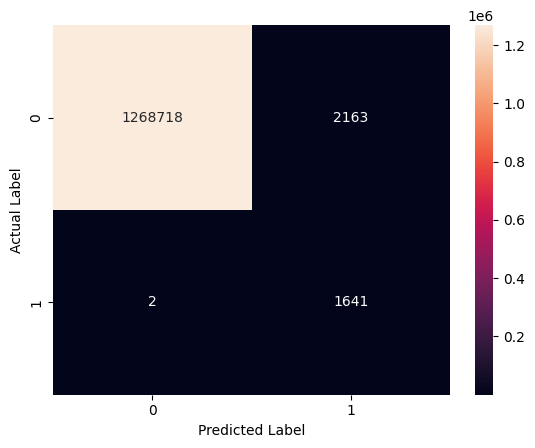

In [ ]:
# cm = confusion_matrix(y_test, rs_y_pred)
# sns.heatmap(cm,annot=True,fmt="d")
# plt.ylabel("Actual Label")
# plt.xlabel("Predicted Label")
# plt.show()

- I am going with the xgboost model which is not hyperparameter tuned
- because before hyperparameter tuning the FN(false negative) value is 30 which to less compared to result what we got previously
- as we are working on fraud detection task our goal is to maximize recall (minimize false negatives), accepting lower precision as a trade-off

# **Random Forest**

## Hyperparameter Tuning

In [ ]:
# rf = RandomForestClassifier(
#         n_estimators=100,
#         class_weight='balanced',
#         random_state=42,
#         n_jobs=-1
#     )

In [ ]:
# param_dist = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [10, 20, None],
#     "min_samples_split": [2, 5, 10],
#     "min_samples_leaf": [1, 2, 4],
#     "max_features": ["sqrt", "log2"]
# }

In [ ]:
# rf_random = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=10,              # keeping small (fast)
#     cv=3,                   # 3-fold CV
#     verbose=2,
#     random_state=42,
#     n_jobs=-1,
#     scoring="recall"            # IMPORTANT for fraud detection
# )

In [ ]:
# rf_random.fit(X_train, y_train) #on cpu it takes 5hrs to run

# Why i am not choosing random forest

- Memory Issues: With 6.3M rows and 14+ columns, Random Forest will consume massive amounts of RAM.

- Underfitting: Random Forest is an "averaging" model. In fraud detection, fraud is an "exception," not an "average." RF often struggles to flag rare events unless the trees are incredibly deep, which leads to massive model sizes.

# Feature Engineering

In [ ]:
# 1. The 'Invisible' money check
df['errorBalanceOrig'] = df['oldbalanceOrg'] - df['amount']
# 2. Flagging accounts emptied to exactly zero
df['is_fully_emptied'] = (df['errorBalanceOrig'] == 0).astype(int)
# 3. Destination balance check (did the money actually arrive?)
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount']

In [ ]:
# 4. Transaction Velocity (How many transactions are happening in this hour?)
# This helps catch 'burst' fraud attacks
df['hourly_velocity'] = df.groupby(['day', 'hour'])['amount'].transform('count')

# 5. Value Deviation
# Is this transaction much larger than the typical transaction for this hour?
avg_hourly_amount = df.groupby('hour')['amount'].transform('mean')
df['amount_deviation'] = df['amount'] / avg_hourly_amount

# 6. Night-time High Value (Combining existing features)
# High amounts at night are riskier than high amounts during the day
df['night_heist'] = (df['is_night'] & df['high_amount']).astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 20 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   amount                   float64
 1   oldbalanceOrg            float64
 2   oldbalanceDest           float64
 3   isFraud                  int64  
 4   hour                     int64  
 5   day                      int64  
 6   high_amount              int64  
 7   zero_balance_before      int64  
 8   amount_to_balance_ratio  float64
 9   is_night                 int64  
 10  type_CASH_OUT            int64  
 11  type_DEBIT               int64  
 12  type_PAYMENT             int64  
 13  type_TRANSFER            int64  
 14  errorBalanceOrig         float64
 15  is_fully_emptied         int64  
 16  errorBalanceDest         float64
 17  hourly_velocity          int64  
 18  amount_deviation         float64
 19  night_heist              int64  
dtypes: float64(7), int64(13)
memory usage: 970.9 M

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Threshold: 0.3
Precision: 0.8338414634146342
Recall: 0.9987827145465612
F1: 0.9088895042924398
------
Threshold: 0.5
Precision: 0.9551282051282052
Recall: 0.9975654290931223
F1: 0.9758856802619827
------
Threshold: 0.7
Precision: 0.974435196195006
Recall: 0.9975654290931223
F1: 0.9858646616541353
------
Threshold: 0.9


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.0
Recall: 0.0
F1: 0.0
------


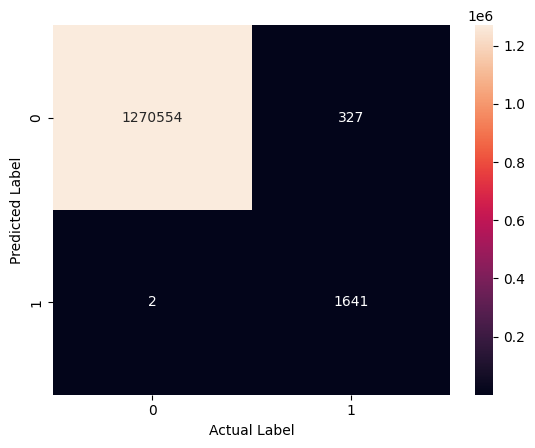

In [ ]:
# X = df.drop(['isFraud'],axis=1)
# y = df['isFraud']

# #train test split
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

# xgb = XGBClassifier(
#         n_estimators=200,
#         max_depth=6,
#         learning_rate=0.1,
#         scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
#         random_state=42,
#         n_jobs=-1,
#         eval_metric='logloss',
#         tree_method='hist' # speed boost
#     )


# param_grid = {
#     "n_estimators": [100, 200, 300],
#     "max_depth": [3, 5, 7],
#     "learning_rate": [0.01, 0.1, 0.2],
#     "subsample": [0.8, 1.0],
#     "colsample_bytree": [0.8, 1.0]
# }

# rs_xgb = RandomizedSearchCV(
#     xgb,
#     param_distributions=param_grid,
#     n_iter=10,
#     cv=3,
#     scoring="recall",
#     verbose=1,
#     n_jobs=-1
# )

# # X_sample = X_train.sample(300000, random_state=42)
# # y_sample = y_train.loc[X_sample.index]

# rs_xgb.fit(X_train, y_train)
# # rs_xgb.fit(X_sample, y_sample)

# rs_y_probs = rs_xgb.predict_proba(X_test)[:,1]

# thresholds = [0.3, 0.5, 0.7, 0.9]

# for t in thresholds:
#     y_pred_t = (rs_y_probs > t).astype(int)

#     print(f"Threshold: {t}")
#     print("Precision:", precision_score(y_test, y_pred_t))
#     print("Recall:", recall_score(y_test, y_pred_t))
#     print("F1:", f1_score(y_test, y_pred_t))
#     print("------")

# rs_y_probs = rs_xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
# rs_y_pred = (rs_y_probs > 0.3).astype(int)


# cm = confusion_matrix(y_test, rs_y_pred)
# sns.heatmap(cm,annot=True,fmt="d")
# plt.ylabel("Actual Label")
# plt.xlabel("Predicted Label")
# plt.show()

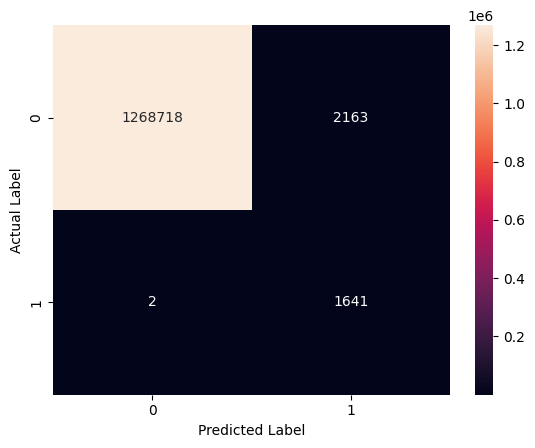

In [ ]:
# rs_y_probs = rs_xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
# rs_y_pred = (rs_y_probs > 0.5).astype(int)


# cm = confusion_matrix(y_test, rs_y_pred)
# sns.heatmap(cm,annot=True,fmt="d")
# plt.ylabel("Actual Label")
# plt.xlabel("Predicted Label")
# plt.show()

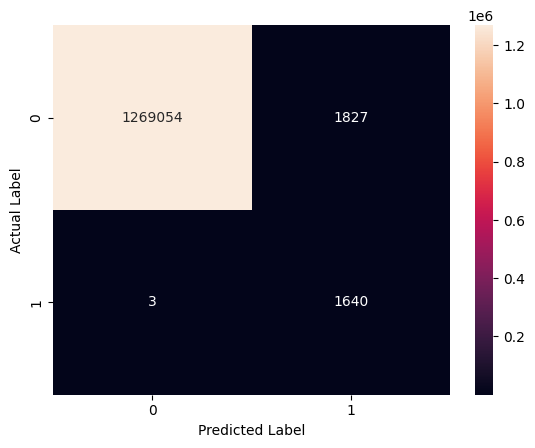

In [ ]:
# rs_y_probs = rs_xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
# rs_y_pred = (rs_y_probs > 0.7).astype(int)


# cm = confusion_matrix(y_test, rs_y_pred)
# sns.heatmap(cm,annot=True,fmt="d")
# plt.ylabel("Actual Label")
# plt.xlabel("Predicted Label")
# plt.show()

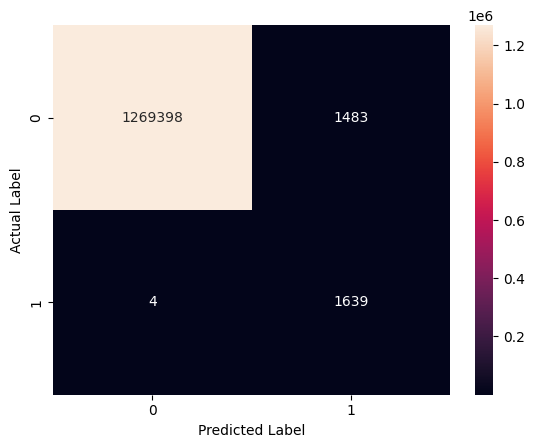

In [ ]:
# rs_y_probs = rs_xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
# rs_y_pred = (rs_y_probs > 0.9).astype(int)


# cm = confusion_matrix(y_test, rs_y_pred)
# sns.heatmap(cm,annot=True,fmt="d")
# plt.ylabel("Actual Label")
# plt.xlabel("Predicted Label")
# plt.show()

- I am getting such a good results because of data leakage in dataset
- data leakage is happening because of errorBalanceOrig, errorBalanceDest, is_fully_emptied
- Although these features can be computed at runtime, they introduce target leakage because they encode inconsistencies specific to the dataset, making the model overly dependent on artificial patterns rather than general fraud behavior.
- when i want to transform a column i fit and trasform on train data and i just transform on test data , because model should not get the hidden patterns from test data ,but i have done this mistake on features like is_fully_emptied and amount_deviation

In [ ]:
df.drop(columns=['errorBalanceOrig','errorBalanceDest','is_fully_emptied','hourly_velocity','amount_deviation','night_heist'],inplace=True)

# Feature Engineering

In [ ]:
X = df.drop(['isFraud'], axis=1)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 13 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   amount                   float64
 1   oldbalanceOrg            float64
 2   oldbalanceDest           float64
 3   hour                     int64  
 4   day                      int64  
 5   high_amount              int64  
 6   zero_balance_before      int64  
 7   amount_to_balance_ratio  float64
 8   is_night                 int64  
 9   type_CASH_OUT            int64  
 10  type_DEBIT               int64  
 11  type_PAYMENT             int64  
 12  type_TRANSFER            int64  
dtypes: float64(4), int64(9)
memory usage: 631.1 MB


## for train data

In [ ]:
X_train['hourly_velocity'] = X_train.groupby(['day','hour'])['amount'].transform('count')

avg_hourly_amount_train = X_train.groupby('hour')['amount'].transform('mean')
X_train['amount_deviation'] = X_train['amount'] / avg_hourly_amount_train

## for test data

In [ ]:
hourly_counts = X_train.groupby(['day','hour'])['amount'].count()
X_test['hourly_velocity'] = X_test.set_index(['day','hour']).index.map(hourly_counts)

hourly_avg = X_train.groupby('hour')['amount'].mean()
X_test['amount_deviation'] = X_test['hour'].map(hourly_avg)

X_test['amount_deviation'] = X_test['amount'] / X_test['amount_deviation']

In [ ]:
xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        tree_method='hist' # speed boost
    )


param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

rs_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="recall",
    verbose=1,
    n_jobs=-1
)

# X_sample = X_train.sample(300000, random_state=42)
# y_sample = y_train.loc[X_sample.index]

rs_xgb.fit(X_train, y_train)
# rs_xgb.fit(X_sample, y_sample)

rs_y_probs = rs_xgb.predict_proba(X_test)[:,1]

thresholds = [0.3, 0.5, 0.7, 0.9]

for t in thresholds:
    y_pred_t = (rs_y_probs > t).astype(int)

    print(f"Threshold: {t}")
    print("Precision:", precision_score(y_test, y_pred_t))
    print("Recall:", recall_score(y_test, y_pred_t))
    print("F1:", f1_score(y_test, y_pred_t))
    print("------")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Threshold: 0.3
Precision: 0.3958031837916064
Recall: 0.9987827145465612
F1: 0.5669372948695802
------
Threshold: 0.5
Precision: 0.4313880126182965
Recall: 0.9987827145465612
F1: 0.602533504681476
------
Threshold: 0.7
Precision: 0.47303143928468416
Recall: 0.9981740718198417
F1: 0.6418786692759295
------
Threshold: 0.9
Precision: 0.5249839846252402
Recall: 0.9975654290931223
F1: 0.6879328436516264
------


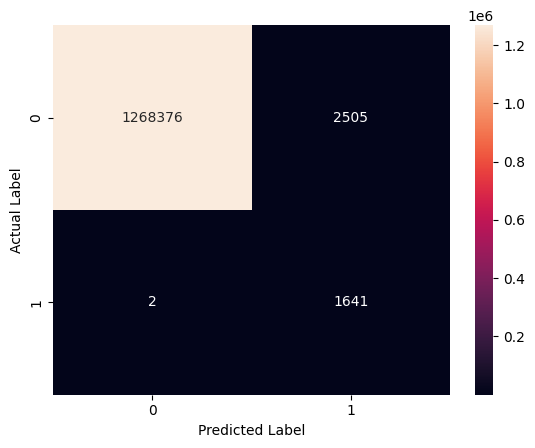

In [ ]:
# rs_y_probs = rs_xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
# rs_y_pred = (rs_y_probs > 0.3).astype(int)


# cm = confusion_matrix(y_test, rs_y_pred)
# sns.heatmap(cm,annot=True,fmt="d")
# plt.ylabel("Actual Label")
# plt.xlabel("Predicted Label")
# plt.show()

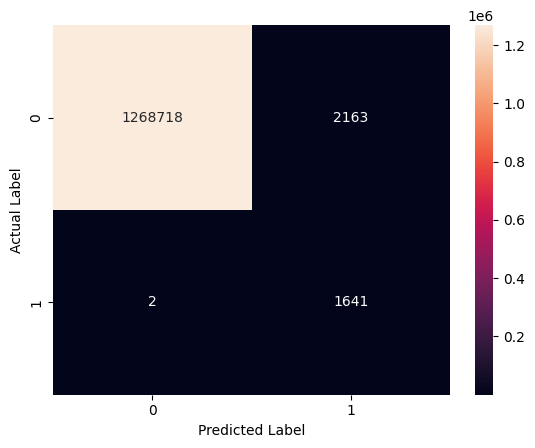

In [ ]:
# rs_y_probs = rs_xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
# rs_y_pred = (rs_y_probs > 0.5).astype(int)


# cm = confusion_matrix(y_test, rs_y_pred)
# sns.heatmap(cm,annot=True,fmt="d")
# plt.ylabel("Actual Label")
# plt.xlabel("Predicted Label")
# plt.show()

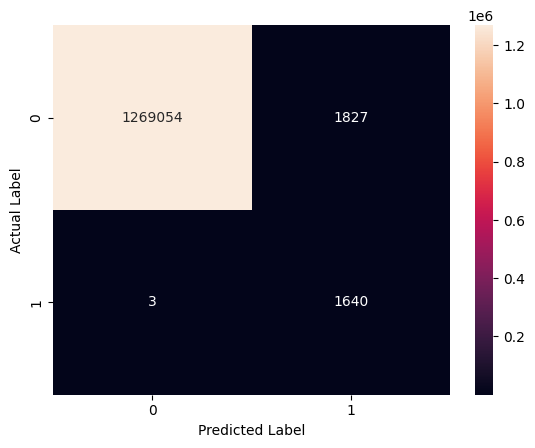

In [ ]:
# rs_y_probs = rs_xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
# rs_y_pred = (rs_y_probs > 0.7).astype(int)


# cm = confusion_matrix(y_test, rs_y_pred)
# sns.heatmap(cm,annot=True,fmt="d")
# plt.ylabel("Actual Label")
# plt.xlabel("Predicted Label")
# plt.show()

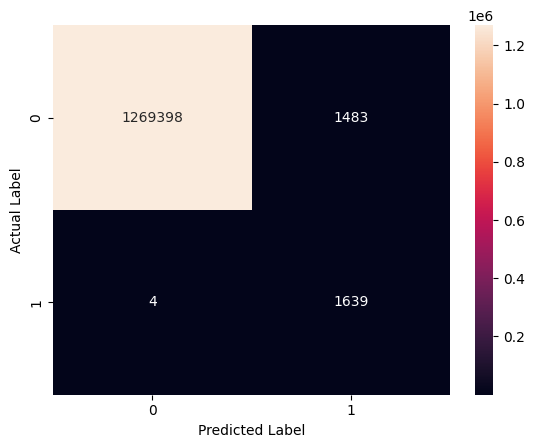

In [ ]:
rs_y_probs = rs_xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
rs_y_pred = (rs_y_probs > 0.9).astype(int)


cm = confusion_matrix(y_test, rs_y_pred)
sns.heatmap(cm,annot=True,fmt="d")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

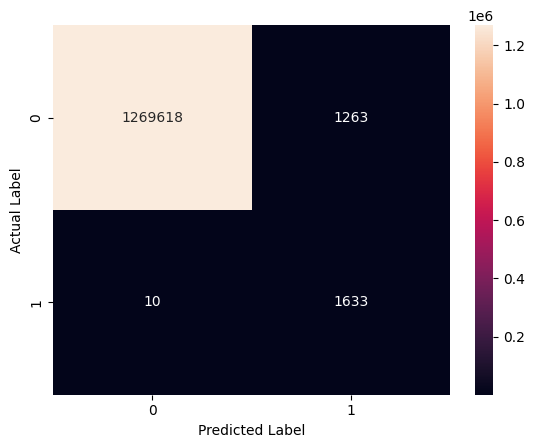

In [ ]:
# rs_y_probs = rs_xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
# rs_y_pred = (rs_y_probs > 0.97).astype(int)


# cm = confusion_matrix(y_test, rs_y_pred)
# sns.heatmap(cm,annot=True,fmt="d")
# plt.ylabel("Actual Label")
# plt.xlabel("Predicted Label")
# plt.show()

# **Finalizing the Model**
- Model = XGBoost (tuned)
- threshold = 0.9

`“The model achieves near-perfect recall, missing only 4 fraud cases, which is critical in financial systems. Although precision is moderate (0.52), this trade-off is acceptable as false positives can be manually reviewed, while missed frauds result in financial loss.”`

In [ ]:
print(rs_xgb.best_params_)

{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [ ]:
rs_xgb.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
rs_y_probs = rs_xgb.predict_proba(X_test)[:,1] #we care about: "What is the probability that this transaction is fraud?"
rs_y_pred = (rs_y_probs > 0.9).astype(int)

In [ ]:
print("Classification Report:\n", classification_report(y_test, rs_y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, rs_y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, rs_y_pred))
print("PR-AUC Score:", average_precision_score(y_test, rs_y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.52      1.00      0.69      1643

    accuracy                           1.00   1272524
   macro avg       0.76      1.00      0.84   1272524
weighted avg       1.00      1.00      1.00   1272524

Confusion Matrix:
 [[1269398    1483]
 [      4    1639]]
ROC-AUC Score: 0.9981992610210146
PR-AUC Score: 0.5237090172488772


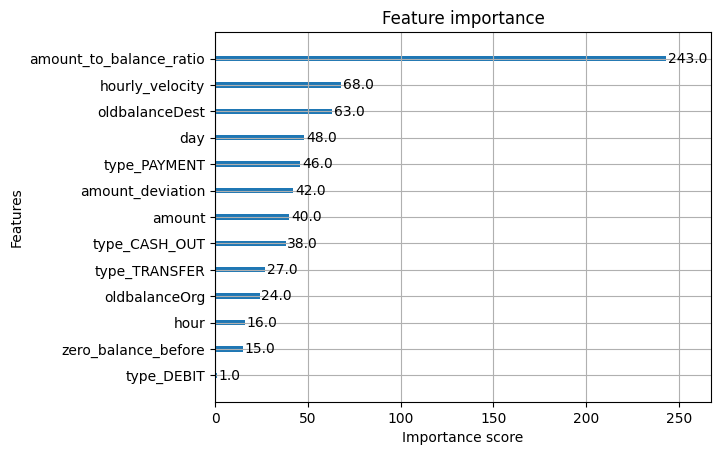

In [ ]:
plot_importance(rs_xgb.best_estimator_)
plt.show()

`“The model heavily relies on amount-to-balance ratio, indicating fraudsters tend to drain accounts. It also captures burst transaction patterns through hourly velocity and leverages transaction types and temporal features to identify suspicious behavior.”`

In [ ]:
import joblib

joblib.dump(rs_xgb.best_estimator_, "/content/drive/MyDrive/fraud_model.pkl")

['/content/drive/MyDrive/fraud_model.pkl']

In [7]:
%pip install scikit-learn xgboost